### Pripojenie Google Drive

In [1]:
from google.colab import drive
import os

# Uistíme sa, že disk je pripojený
drive.mount('/content/drive')

# Vypíšeme všetky priečinky pre manuálnu kontrolu
print("Zoznam priečinkov na My Drive:")
my_drive_path = '/content/drive/MyDrive/'
folders = [f for f in os.listdir(my_drive_path) if os.path.isdir(os.path.join(my_drive_path, f))]
for f in folders:
    print(f" - {f}")

# Skúsime automaticky nájsť priečinok, ktorý obsahuje CSV súbory
print("\nHľadám Fashion-MNIST súbory...")
found_path = None
for root, dirs, files in os.walk(my_drive_path):
    if 'fashion-mnist_train.csv' in files:
        found_path = root
        break

if found_path:
    print(f"✅ Našiel som dáta v: {found_path}")
    print("Obsah:", os.listdir(found_path))
else:
    print("❌ Súbor 'fashion-mnist_train.csv' sa nenašiel. Uistite sa, že ste si priečinok z linku pridali na svoj disk (Skratka / Shortcut).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zoznam priečinkov na My Drive:
 - Office 2016.zip (Unzipped Files)
 - Riša merania
 - Testy
 - ima2c
 - zmluva
 - birmovka
 - knn
 - musicology
 - Colab Notebooks
 - VYF2
 - VYF3
 - VYF1
 - VYF
 - CV
 - SportsClassifier
 - small-e-czech-sport
 - small-e-czech-sport_clean_merged
 - small-e-czech-sport_clean_aug
 - small-e-czech-sport_clean_aug_focus2
 - small-e-czech-sport_clean_aug_focus_w07
 - small-e-czech-sport_clean_aug_focus_w1
 - small-e-czech-sport_clean_aug_focus_w13
 - small-e-czech-sport_clean_aug_focus_w07epoch5
 - small-e-czech-sport_clean_aug_focus_train
 - chatarena
 - AIBiz-2026-spring

Hľadám Fashion-MNIST súbory...
✅ Našiel som dáta v: /content/drive/MyDrive/AIBiz-2026-spring/ai-biz-2026-spring-task-3
Obsah: ['fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'fashion-mnist_test_sample_submission.csv']


# Fashion-MNIST Task 3: Transfer Learning with EfficientNet

This notebook trains an EfficientNetB0-based classifier for Fashion-MNIST CSV data and creates `submission.csv` in the main folder.

In [2]:
# If needed in Colab, uncomment:
# !pip install -q tensorflow pandas scikit-learn seaborn

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Data path: local first, then common Colab drive fallback
LOCAL_DATA_DIR = './ai-biz-2026-spring-task-3'
COLAB_DATA_DIR = '/content/drive/MyDrive/AIBiz-2026-spring/ai-biz-2026-spring-task-3'

if os.path.exists(LOCAL_DATA_DIR):
    DATA_DIR = LOCAL_DATA_DIR
elif os.path.exists(COLAB_DATA_DIR):
    DATA_DIR = COLAB_DATA_DIR
else:
    raise FileNotFoundError('Could not find dataset directory. Set DATA_DIR manually.')

TRAIN_PATH = os.path.join(DATA_DIR, 'fashion-mnist_train.csv')
TEST_PATH = os.path.join(DATA_DIR, 'fashion-mnist_test.csv')
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, 'fashion-mnist_test_sample_submission.csv')

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print('DATA_DIR:', DATA_DIR)
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print(sample_sub.head())

DATA_DIR: /content/drive/MyDrive/AIBiz-2026-spring/ai-biz-2026-spring-task-3
Train shape: (60000, 785)
Test shape: (10000, 784)
   imageID  label
0        0      2
1        1      1
2        2      9
3        3      1
4        4      6


In [4]:
# Prepare arrays
y = train_df['label'].values.astype(np.int64)
X = train_df.drop(columns=['label']).values.astype(np.float32) / 255.0
X_test = test_df.values.astype(np.float32) / 255.0

X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=SEED, stratify=y
)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:', X_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape)

X_train: (54000, 28, 28, 1) y_train: (54000,)
X_val: (6000, 28, 28, 1) y_val: (6000,)
X_test: (10000, 28, 28, 1)


In [10]:
# Config
NUM_CLASSES = 10
BATCH_SIZE = 256
AUTO = tf.data.AUTOTUNE

SEEDS = [11, 23, 47]
EPOCHS_BASE = 24
EPOCHS_SPEC = 20

CONFUSION_CLASSES = [0, 2, 4, 6]
SHIRT_CLASS = 6

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

def make_sparse_cce(label_smoothing=0.0):
    # TF versions differ: some builds do not support label_smoothing for sparse CE.
    try:
        return keras.losses.SparseCategoricalCrossentropy(label_smoothing=label_smoothing)
    except TypeError:
        if label_smoothing > 0:
            print('SparseCategoricalCrossentropy without label_smoothing support in this TF build; using smoothing=0.0')
        return keras.losses.SparseCategoricalCrossentropy()

print('Confusion classes:', CONFUSION_CLASSES)

Confusion classes: [0, 2, 4, 6]


In [6]:
# tf.data helpers
def make_base_train_dataset(X_arr, y_arr, seed=SEED):
    aug = keras.Sequential([
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.08),
    ], name='aug')

    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    ds = ds.shuffle(len(X_arr), seed=seed)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=AUTO)
    return ds.prefetch(AUTO)

def make_eval_dataset(X_arr, y_arr=None):
    if y_arr is None:
        ds = tf.data.Dataset.from_tensor_slices(X_arr)
        return ds.batch(BATCH_SIZE).prefetch(AUTO)
    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    return ds.batch(BATCH_SIZE).prefetch(AUTO)

In [7]:
# Base model: compact grayscale ResNet-like CNN
def residual_block(x, filters, stride=1, drop=0.0, name='rb'):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False, name=f'{name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.Activation('swish', name=f'{name}_act1')(x)

    x = layers.Conv2D(filters, 3, padding='same', use_bias=False, name=f'{name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False, name=f'{name}_proj_conv')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_proj_bn')(shortcut)

    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('swish', name=f'{name}_act2')(x)
    if drop > 0:
        x = layers.Dropout(drop, name=f'{name}_drop')(x)
    return x

def build_base_model(num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, name='stem_conv')(inputs)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation('swish', name='stem_act')(x)

    x = residual_block(x, 64, stride=1, drop=0.05, name='b1_1')
    x = residual_block(x, 64, stride=1, drop=0.05, name='b1_2')

    x = residual_block(x, 128, stride=2, drop=0.10, name='b2_1')
    x = residual_block(x, 128, stride=1, drop=0.10, name='b2_2')

    x = residual_block(x, 256, stride=2, drop=0.15, name='b3_1')
    x = residual_block(x, 256, stride=1, drop=0.15, name='b3_2')

    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.25, name='head_drop')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='classifier')(x)

    return keras.Model(inputs, outputs, name='fmnist_resnet_small')

In [8]:
# Train 3-seed base ensemble
base_val_probs_list = []
base_test_probs_list = []
histories = []

val_ds = make_eval_dataset(X_val, y_val)
test_ds = make_eval_dataset(X_test)

for i, seed in enumerate(SEEDS, start=1):
    print(f'\n===== Base model seed {seed} ({i}/{len(SEEDS)}) =====')
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = build_base_model()

    if hasattr(keras.optimizers, 'AdamW'):
        optimizer = keras.optimizers.AdamW(learning_rate=2e-3, weight_decay=1e-4)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=2e-3)

    model.compile(
        optimizer=optimizer,
        loss=make_sparse_cce(label_smoothing=0.02),
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ]

    train_ds = make_base_train_dataset(X_train, y_train, seed=seed)
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_BASE,
        callbacks=callbacks,
        verbose=1
    )
    histories.append(hist.history)

    val_probs = model.predict(val_ds.map(lambda x, y: x), verbose=0)
    test_probs = model.predict(test_ds, verbose=0)

    base_val_probs_list.append(val_probs)
    base_test_probs_list.append(test_probs)

base_val_probs = np.mean(base_val_probs_list, axis=0)
base_test_probs = np.mean(base_test_probs_list, axis=0)

base_val_pred = np.argmax(base_val_probs, axis=1)
base_val_acc = accuracy_score(y_val, base_val_pred)
base_shirt_f1 = f1_score((y_val == SHIRT_CLASS).astype(int), (base_val_pred == SHIRT_CLASS).astype(int))

print(f'\nBase ensemble val_acc: {base_val_acc:.5f}')
print(f'Base ensemble Shirt F1: {base_shirt_f1:.5f}')


===== Base model seed 11 (1/3) =====
SparseCategoricalCrossentropy without label_smoothing support in this TF build; using smoothing=0.0
Epoch 1/24
53/53 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.6723 - loss: 0.8961 - val_accuracy: 0.1000 - val_loss: 5.3064 - learning_rate: 0.0020
Epoch 2/24
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 598ms/step - accuracy: 0.8054 - loss: 0.5161 - val_accuracy: 0.1000 - val_loss: 4.2923 - learning_rate: 0.0020
Epoch 3/24
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.8398 - loss: 0.4291
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 603ms/step - accuracy: 0.8471 - loss: 0.4102 - val_accuracy: 0.1000 - val_loss: 7.7015 - learning_rate: 0.0020
Epoch 4/24
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 596ms/step - accuracy: 0.8699 - loss: 0.3476 - val_accuracy: 0.1280 - val_loss: 4.8701 - learning_rate: 0.0010
Epoch 5/24
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 599ms/step - accuracy: 0.8850 - loss: 0.3137 - val_accuracy

In [11]:
# Specialist model on confusion classes {0,2,4,6}
spec_class_to_idx = {c: i for i, c in enumerate(CONFUSION_CLASSES)}
idx_to_spec_class = {i: c for c, i in spec_class_to_idx.items()}

train_mask_spec = np.isin(y_train, CONFUSION_CLASSES)
val_mask_spec = np.isin(y_val, CONFUSION_CLASSES)

X_train_spec = X_train[train_mask_spec]
y_train_spec = np.array([spec_class_to_idx[v] for v in y_train[train_mask_spec]], dtype=np.int64)

X_val_spec = X_val[val_mask_spec]
y_val_spec = np.array([spec_class_to_idx[v] for v in y_val[val_mask_spec]], dtype=np.int64)

print('Specialist train:', X_train_spec.shape, y_train_spec.shape)
print('Specialist val:', X_val_spec.shape, y_val_spec.shape)
print('Specialist train class counts:', np.bincount(y_train_spec, minlength=len(CONFUSION_CLASSES)))
print('Specialist val class counts:', np.bincount(y_val_spec, minlength=len(CONFUSION_CLASSES)))

specialist = build_base_model(num_classes=len(CONFUSION_CLASSES))
if hasattr(keras.optimizers, 'AdamW'):
    spec_opt = keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4, clipnorm=1.0)
else:
    spec_opt = keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)

specialist.compile(
    optimizer=spec_opt,
    loss=make_sparse_cce(label_smoothing=0.01),
    metrics=['accuracy']
)

spec_callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
]

train_spec_ds = make_base_train_dataset(X_train_spec, y_train_spec, seed=SEED + 100)
val_spec_ds = make_eval_dataset(X_val_spec, y_val_spec)

specialist.fit(
    train_spec_ds,
    validation_data=val_spec_ds,
    epochs=EPOCHS_SPEC,
    callbacks=spec_callbacks,
    verbose=1
)

# Predict on full val/test to support routing; these datasets yield only images.
spec_val_probs_4 = specialist.predict(make_eval_dataset(X_val), verbose=0)
spec_test_probs_4 = specialist.predict(make_eval_dataset(X_test), verbose=0)

Specialist train: (21600, 28, 28, 1) (21600,)
Specialist val: (2400, 28, 28, 1) (2400,)
Specialist train class counts: [5400 5400 5400 5400]
Specialist val class counts: [600 600 600 600]
SparseCategoricalCrossentropy without label_smoothing support in this TF build; using smoothing=0.0
Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 61s 392ms/step - accuracy: 0.6122 - loss: 0.9178 - val_accuracy: 0.2500 - val_loss: 1.7247 - learning_rate: 5.0000e-04
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.7317 - loss: 0.6450 - val_accuracy: 0.2500 - val_loss: 2.1530 - learning_rate: 5.0000e-04
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.7832 - loss: 0.5427 - val_accuracy: 0.2871 - val_loss: 2.4070 - learning_rate: 5.0000e-04
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.8078 - loss: 0.4896 - val_accuracy: 0.3892 - val_loss: 1.9595 - learning_rate: 5.0000e-04
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.8249 - loss: 0.44

In [12]:
# Routing + fusion: use specialist on uncertain confusion predictions
conf_arr = np.array(CONFUSION_CLASSES)

def fuse_with_specialist(base_probs, spec_probs_4, route_margin=0.15, blend=0.8):
    fused = base_probs.copy()

    top1 = np.argmax(base_probs, axis=1)
    sorted_probs = np.sort(base_probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    route_mask = ((np.isin(top1, conf_arr) & (margin < route_margin)) | (top1 == SHIRT_CLASS))
    route_idx = np.where(route_mask)[0]

    if len(route_idx) == 0:
        return fused, route_idx

    base_conf = fused[np.ix_(route_idx, conf_arr)]
    spec_conf = spec_probs_4[route_idx]

    mixed_conf = (1.0 - blend) * base_conf + blend * spec_conf

    fused[np.ix_(route_idx, conf_arr)] = mixed_conf
    fused[route_idx] = fused[route_idx] / np.sum(fused[route_idx], axis=1, keepdims=True)

    return fused, route_idx

# Grid-search on validation for shirt-focused objective
best = None
for route_margin in [0.08, 0.12, 0.16, 0.20]:
    for blend in [0.60, 0.75, 0.90]:
        val_fused_probs, routed = fuse_with_specialist(base_val_probs, spec_val_probs_4, route_margin, blend)
        val_fused_pred = np.argmax(val_fused_probs, axis=1)

        acc = accuracy_score(y_val, val_fused_pred)
        shirt_f1 = f1_score((y_val == SHIRT_CLASS).astype(int), (val_fused_pred == SHIRT_CLASS).astype(int))

        candidate = (shirt_f1, acc, route_margin, blend, len(routed))
        if best is None or (candidate[0] > best[0]) or (candidate[0] == best[0] and candidate[1] > best[1]):
            best = candidate

best_shirt_f1, best_acc, best_margin, best_blend, best_routed = best
print('Best fusion config:')
print(f'  route_margin={best_margin:.2f}, blend={best_blend:.2f}, routed_samples={best_routed}')
print(f'  val_acc={best_acc:.5f}, shirt_f1={best_shirt_f1:.5f}')

val_probs, routed_val_idx = fuse_with_specialist(base_val_probs, spec_val_probs_4, best_margin, best_blend)
test_probs, routed_test_idx = fuse_with_specialist(base_test_probs, spec_test_probs_4, best_margin, best_blend)

val_pred = np.argmax(val_probs, axis=1)
val_acc = accuracy_score(y_val, val_pred)
shirt_f1 = f1_score((y_val == SHIRT_CLASS).astype(int), (val_pred == SHIRT_CLASS).astype(int))

print(f'\nFinal fused val_acc: {val_acc:.5f}')
print(f'Final fused Shirt F1: {shirt_f1:.5f}')
print(f'Routed val samples: {len(routed_val_idx)} / {len(y_val)}')

Best fusion config:
  route_margin=0.16, blend=0.60, routed_samples=650
  val_acc=0.94367, shirt_f1=0.82728

Final fused val_acc: 0.94367
Final fused Shirt F1: 0.82728
Routed val samples: 650 / 6000


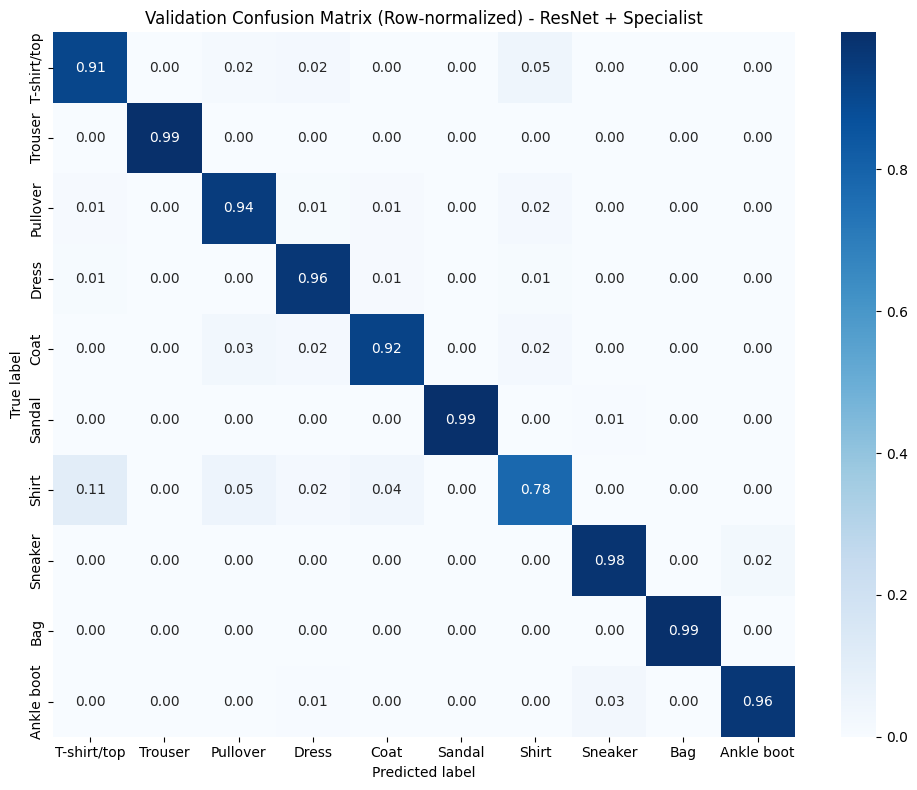

              precision    recall  f1-score   support

 T-shirt/top     0.8724    0.9117    0.8916       600
     Trouser     0.9983    0.9933    0.9958       600
    Pullover     0.8970    0.9433    0.9196       600
       Dress     0.9205    0.9650    0.9422       600
        Coat     0.9357    0.9217    0.9286       600
      Sandal     0.9983    0.9900    0.9941       600
       Shirt     0.8828    0.7783    0.8273       600
     Sneaker     0.9654    0.9767    0.9710       600
         Bag     0.9933    0.9933    0.9933       600
  Ankle boot     0.9731    0.9633    0.9682       600

    accuracy                         0.9437      6000
   macro avg     0.9437    0.9437    0.9432      6000
weighted avg     0.9437    0.9437    0.9432      6000



In [13]:
# Confusion matrix + per-class report
cm = confusion_matrix(y_val, val_pred)
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Validation Confusion Matrix (Row-normalized) - ResNet + Specialist')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

print(classification_report(y_val, val_pred, target_names=CLASS_NAMES, digits=4))

In [14]:
# Submission
test_pred = np.argmax(test_probs, axis=1)
submission = sample_sub.copy()
submission['label'] = test_pred

submission_path = './submission_resnet_specialist.csv'
submission.to_csv(submission_path, index=False)
np.save('./test_probs_resnet_specialist.npy', test_probs)

print('Saved submission:', submission_path)
print('Saved test probabilities: ./test_probs_resnet_specialist.npy')
submission.head()

Saved submission: ./submission_resnet_specialist.csv
Saved test probabilities: ./test_probs_resnet_specialist.npy


,imageID,label
0,0,0
1,1,1
2,2,2
3,3,2
4,4,3
